# Reproducing Zuend et al. (2010): LLE stability & RH-dependent gas/particle partitioning

This notebook exercises `aiomfac_py` against figures from:

> Zuend, A., Marcolli, C., Peter, T., Seinfeld, J. H. (2010), "Computation of liquid-liquid equilibria and
> phase stabilities: implications for RH-dependent gas/particle partitioning of organic-inorganic aerosols",
> *Atmos. Chem. Phys.*, 10, 7795-7820, doi:[10.5194/acp-10-7795-2010](https://doi.org/10.5194/acp-10-7795-2010).

Like `02_reproduce_zuend2008.ipynb`, this is a completeness test of the Python port, not a paper-reproduction
package -- please read the honesty table at the very end before trusting any panel here.

This paper asks much more of `aiomfac_py` than the 2008 one: liquid-liquid **stability** (not just the
equilibrium phase split) and full RH-dependent **gas/particle partitioning**. Two new modules were added to
the package to support it:

- **`aiomfac_py.spinodal`** -- the tangent-plane Gibbs-energy Hessian determinant `L` (paper Eq. 18-20),
  evaluated by direct finite differences in the independent mole fractions. `L > 0` stable/metastable,
  `L < 0` inside the spinodal (unconditionally unstable), `L = 0` the spinodal boundary itself.
- **`aiomfac_py.gp_partition`** -- RH-dependent gas/particle partitioning (paper Eq. 21-24), coupling
  modified Raoult's law in the gas phase to `aiomfac_py.lle.solve_pep` in the particle phase, solved by plain
  successive substitution rather than the paper's Differential-Evolution/Powell/Levenberg-Marquardt
  combination (Appendix A).

Read each module's docstring (`help(aiomfac_py.spinodal)` / `help(aiomfac_py.gp_partition)`) for the full
"how closely does this match the paper" account before trusting any number below. As in notebook 02, no
digitized data from the paper's own figures is used for the curves computed here (only the small validation
overlays noted explicitly where they occur) -- read the plots as "AIOMFAC-predicted, in the same style and for
the same systems as Fig. X", not as a pixel overlay of the published figure.

### Setup

In [1]:
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/aiomfac-python")

try:
    import aiomfac_py as aiomfac
except ImportError:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)],
                        check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate")
    import aiomfac_py as aiomfac

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from aiomfac_py import Component, ActivityModel
from aiomfac_py.lle import solve_pep, AiomfacGFE
from aiomfac_py.spinodal import stability_map, stability_determinant
from aiomfac_py.gp_partition import VolatileSpecies, gp_partition, distinct_phases

print(f"aiomfac_py {aiomfac.__version__}")

aiomfac_py Colab setup
Repo dir : /content/aiomfac-python
Extras   : carbonate
Editable : True
Clean    : False

Installing aiomfac_py with extras [carbonate] ...
$ /usr/bin/python3 -m pip install -q -e .[carbonate]

Verifying installation (in this process, not a subprocess)...
aiomfac_py 0.0.17  (validated against AIOMFAC-web commit b9cb96d0eb22)
  scipy 1.16.3 OK

aiomfac_py setup complete!

Next steps:
  from aiomfac_py import read_input_file, ActivityModel
  (pass --smiles above, or `pip install aiomfac_py[smiles]`, to enable
   aiomfac_py.s2as, SMILES -> AIOMFAC subgroups)
  See notebooks/01_quickstart.ipynb for worked examples.
aiomfac_py 0.0.17


### Shared helpers

`n_real_phases`/`distinct_phases` filter out the same numerically-spurious near-zero-weight or
near-duplicate phases noted in `02_reproduce_zuend2008.ipynb`. `phase_count_grid` sweeps a ternary
(water / organic-or-alcohol / salt) system over a grid of (water-free solute fraction, water mole fraction)
and classifies each point by number of real coexisting phases -- this is this notebook's binodal-region
estimate, used in place of the paper's DE-traced binodal curve (see `lle.py`/`spinodal.py` docstrings for
why: same physics, a cheaper/blunter search strategy). `spinodal_L_grid` does the analogous sweep of the
stability determinant `L` itself, the paper's own Fig. 5/6 quantity.

In [2]:
def n_real_phases(res, y_min=1e-3, dx_min=1e-3):
    keep = [i for i in range(len(res.y)) if res.y[i] > y_min]
    if len(keep) <= 1:
        return 1
    xs = res.x[keep]
    for i in range(len(keep)):
        for j in range(i + 1, len(keep)):
            if np.max(np.abs(xs[i] - xs[j])) > dx_min:
                return len(keep)
    return 1


def phase_count_grid(components, x_solute_wf_grid, x_water_grid, T_K=298.15, tol=1e-7, max_outer=150):
    # components = [water, organic-or-alcohol, salt]. Returns (XSWF, XW, NPH) meshgrid arrays: NPH is the
    # number of real coexisting phases at each (x_solute_water_free, x_water) grid point.
    XSWF, XW = np.meshgrid(x_solute_wf_grid, x_water_grid, indexing="xy")
    NPH = np.full(XSWF.shape, np.nan)
    for i in range(XSWF.shape[0]):
        for j in range(XSWF.shape[1]):
            xswf, xw = XSWF[i, j], XW[i, j]
            x_org = (1 - xw) * (1 - xswf)
            x_salt = (1 - xw) * xswf
            b = np.array([xw, x_org, x_salt])
            if x_org < 1e-10 or x_salt < 1e-10 or xw < 1e-10:
                NPH[i, j] = 1
                continue
            try:
                res = solve_pep(components, b, T_K, tol=tol, max_outer=max_outer)
                NPH[i, j] = n_real_phases(res) if res.converged else np.nan
            except Exception:
                NPH[i, j] = np.nan
    return XSWF, XW, NPH


def spinodal_L_grid(components, x_solute_wf_grid, x_water_grid, T_K=298.15, dep_index=2):
    # Same grid convention as phase_count_grid, but the stability determinant L (spinodal.py) instead of a
    # full LLE solve at every point -- much cheaper (forward AIOMFAC evaluation + one finite-difference
    # Hessian, no Newton/active-set iteration), which is why it can afford a finer grid.
    gfe = AiomfacGFE(components, T_K)
    XSWF, XW = np.meshgrid(x_solute_wf_grid, x_water_grid, indexing="xy")
    L = np.full(XSWF.shape, np.nan)
    for i in range(XSWF.shape[0]):
        for j in range(XSWF.shape[1]):
            xswf, xw = XSWF[i, j], XW[i, j]
            x_org = (1 - xw) * (1 - xswf)
            x_salt = (1 - xw) * xswf
            if x_org < 1e-6 or x_salt < 1e-6 or xw < 1e-6:
                continue
            try:
                L[i, j] = stability_determinant(gfe, np.array([xw, x_org, x_salt]), dep_index=dep_index)
            except Exception:
                pass
    return XSWF, XW, L


def plot_stability_panel(ax, XSWF, XW, L, title, binodal=None):
    Lc = np.clip(L, -50, 50)
    vmin = np.nanmin(Lc) if np.isfinite(np.nanmin(Lc)) else -1.0
    vmax = np.nanmax(Lc) if np.isfinite(np.nanmax(Lc)) else 1.0
    if vmin >= 0:
        vmin = -abs(vmax) * 0.01 - 1e-6
    if vmax <= 0:
        vmax = abs(vmin) * 0.01 + 1e-6
    norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(XSWF, XW, Lc, cmap="RdBu", norm=norm, shading="auto")
    ax.contour(XSWF, XW, L, levels=[0], colors="k", linewidths=1.2, linestyles=":")
    if binodal is not None:
        xswf_b, xw_b, nph_b = binodal
        ax.contour(xswf_b, xw_b, nph_b, levels=[1.5], colors="k", linewidths=1.5)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("x(salt), water-free")
    ax.set_ylabel("x(water)")
    return pc

## Fig. 2 -- 2-propanol + water + NaCl phase diagram

The paper's Fig. 2 example system (Sect. 2.4.2) is 2-propanol + water + NaCl, with real binodal data from
De Santis et al. (1976) and Gomis et al. (1994). The De Santis et al. (1976) points still aren't available to
us (no digitized table), but Gomis et al. (1994) -- the second of the paper's two cited sources, and the one
also used for the NaCl + 1-/2-propanol tie lines overlaid on `02_reproduce_zuend2008.ipynb`'s Fig. 9 -- gives
five directly usable tie lines for exactly this system (water + NaCl + 2-propanol, Table 3 of that paper), so
those are overlaid on panel (a) below as a real-data check on the model's two-phase region.

Panel (a) below is a phase-count map: for a grid of (water-free NaCl mole fraction, water mole fraction), the
LLE solver (`aiomfac_py.lle.solve_pep`) is run and each point classified by its number of real coexisting
phases -- the region where it returns 2 is this notebook's binodal-region estimate, in place of the paper's
traced binodal curve; the black markers are the real Gomis et al. (1994) tie-line endpoints, which should sit
on or near the model's 1-phase/2-phase boundary if the model's binodal region is right. Panel (b) is the water
activity at the same grid points (forced-single-phase style overview, following Fig. 3/4's own two-coordinate
convention from `02_reproduce_zuend2008.ipynb`).


Fig. 2 phase-count grid: 410.2 s, 5 non-converged points


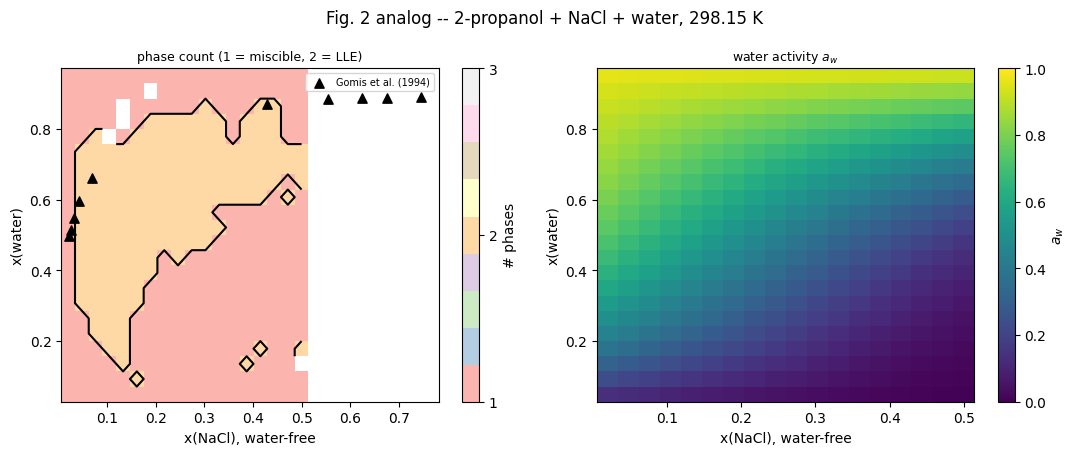

In [3]:
water = Component(1, "Water", ((16, 1),))
propanol2 = Component(2, "2-propanol", ((141, 2), (151, 1), (153, 1)))
nacl = Component(3, "NaCl", ((202, 1), (242, 1)))
comps_f2 = [water, propanol2, nacl]

t0 = time.time()
xswf_grid = np.linspace(0.02, 0.5, 18)
xw_grid = np.linspace(0.05, 0.95, 22)
XSWF2, XW2, NPH2 = phase_count_grid(comps_f2, xswf_grid, xw_grid, tol=1e-7, max_outer=150)
print(f"Fig. 2 phase-count grid: {time.time() - t0:.1f} s, {np.isnan(NPH2).sum()} non-converged points")

model_f2 = ActivityModel(comps_f2)
AW2 = np.full(XSWF2.shape, np.nan)
for i in range(XSWF2.shape[0]):
    for j in range(XSWF2.shape[1]):
        xswf, xw = XSWF2[i, j], XW2[i, j]
        x_org = (1 - xw) * (1 - xswf)
        x_salt = (1 - xw) * xswf
        try:
            res = model_f2.evaluate([xw, x_org, x_salt], 298.15, basis="mole")
            AW2[i, j] = res.activity[0]
        except Exception:
            pass

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4.6))
fig.suptitle("Fig. 2 analog -- 2-propanol + NaCl + water, 298.15 K")
pc = axa.pcolormesh(XSWF2, XW2, NPH2, cmap="Pastel1", vmin=1, vmax=3, shading="auto")
axa.contour(XSWF2, XW2, NPH2, levels=[1.5], colors="k", linewidths=1.5)
axa.set_title("phase count (1 = miscible, 2 = LLE)", fontsize=9)
axa.set_xlabel("x(NaCl), water-free"); axa.set_ylabel("x(water)")
plt.colorbar(pc, ax=axa, ticks=[1, 2, 3], label="# phases")

pc2 = axb.pcolormesh(XSWF2, XW2, AW2, cmap="viridis", vmin=0, vmax=1, shading="auto")
axb.set_title("water activity $a_w$", fontsize=9)
axb.set_xlabel("x(NaCl), water-free"); axb.set_ylabel("x(water)")
plt.colorbar(pc2, ax=axb, label="$a_w$")

# Real tie-line data: Gomis, Ruiz, De Vera, Lopez & Saquete (1994), Fluid Phase Equilib. 98, 141-147,
# Table 3 -- water(1) + NaCl(2) + 2-propanol(3), mass fractions, 25 C. Each row is one tie line's
# (aqueous phase, organic phase); converted below to this panel's own (x_swf, x_w) coordinates.
_gomis1994_wtfrac = {
    "aqueous": [(0.712, 0.213, 0.075), (0.706, 0.197, 0.097), (0.707, 0.181, 0.112),
                (0.700, 0.164, 0.136), (0.671, 0.139, 0.190)],
    "organic": [(0.228, 0.017, 0.755), (0.242, 0.019, 0.739), (0.267, 0.023, 0.710),
                (0.306, 0.029, 0.665), (0.371, 0.042, 0.587)],
}
_M_water, _M_NaCl, _M_2propanol = 18.015, 58.44, 60.10
for _phase, _rows in _gomis1994_wtfrac.items():
    _pts = []
    for _w_w, _w_s, _w_o in _rows:
        _n_w, _n_s, _n_o = _w_w / _M_water, _w_s / _M_NaCl, _w_o / _M_2propanol
        _tot = _n_w + _n_s + _n_o
        _xw, _xswf = _n_w / _tot, (_n_s / _tot) / (_n_s / _tot + _n_o / _tot)
        _pts.append((_xswf, _xw))
    _pts = np.array(_pts)
    axa.scatter(_pts[:, 0], _pts[:, 1], marker="^", s=45, color="k", zorder=5,
                label="Gomis et al. (1994)" if _phase == "aqueous" else None)
axa.legend(fontsize=7, loc="upper right")

plt.tight_layout(); plt.show()

**What the overlay actually shows.** The five Gomis et al. (1994) tie lines don't line up cleanly with the model's predicted 1-phase/2-phase boundary: three of the five organic-phase (2-propanol-rich) points fall at $x_{swf}>0.5$, off the right edge of this grid, and most of the aqueous-phase points sit inside the model's predicted *miscible* (1-phase) region rather than on its boundary. This is the same kind of discrepancy flagged in `02_reproduce_zuend2008.ipynb`'s Fig. 9 section -- AIOMFAC's own activity-coefficient surface for alcohol/NaCl/water mixtures at these concentrations doesn't exactly reproduce the measured phase boundary, independent of the solver -- so this grid should be read as "the model's own, qualitatively-similar two-phase region" rather than a validated match to the real binodal.


## Fig. 5 -- phase stability diagram, 2-propanol + water + NaCl

The paper's own Fig. 5 is the dedicated stability diagram (determinant `L`, Eq. 18-20) for this same system.
Reproduced here with `aiomfac_py.spinodal.stability_map` on a finer grid than Fig. 2 above (cheap -- no LLE
Newton solve needed, just a forward AIOMFAC evaluation and one finite-difference Hessian per point), with the
Fig. 2 binodal-region estimate overlaid as a solid black contour for comparison against the `L = 0` spinodal
(dotted).

/usr/local/lib/python3.13/dist-packages/numpy/linalg/_linalg.py:2432: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Fig. 5 stability grid: 20.0 s


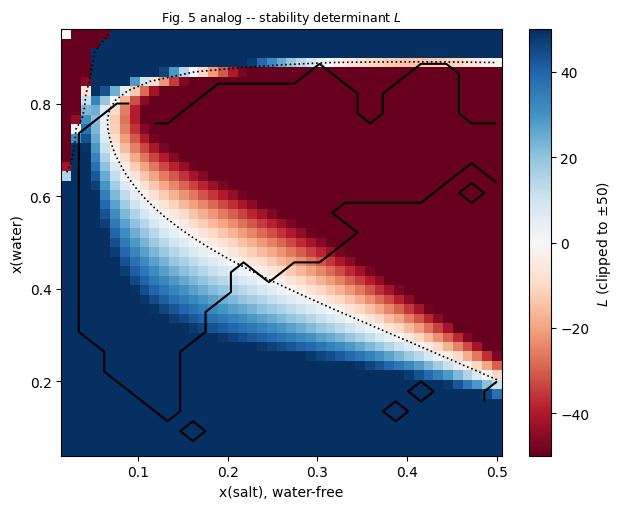

In [4]:
t0 = time.time()
xswf_fine = np.linspace(0.02, 0.5, 45)
xw_fine = np.linspace(0.05, 0.95, 45)
XSWF5, XW5, L5 = spinodal_L_grid(comps_f2, xswf_fine, xw_fine)
print(f"Fig. 5 stability grid: {time.time() - t0:.1f} s")

fig, ax = plt.subplots(figsize=(6.4, 5.2))
pc = plot_stability_panel(ax, XSWF5, XW5, L5, "Fig. 5 analog -- stability determinant $L$",
                           binodal=(XSWF2, XW2, NPH2))
plt.colorbar(pc, ax=ax, label="$L$ (clipped to $\\pm$50)")
plt.tight_layout(); plt.show()

## Fig. 6 -- further ternary alcohol/polyol-water-salt phase diagrams

The paper's Fig. 6 is a 6-panel grid of stability diagrams for different alcohol/polyol + salt + water
systems (Sect. 2.7), several validated against real solubility-curve data. The two alcohol systems, (a) and
(b), have such data (De Santis et al. 1976/Li et al. 1995 for panel a; Lynn et al. 1996/Brenner et al. 1992
for panel b) -- again not available to me as digitized numbers, so not overlaid. The 4 polyol + (NH4)2SO4
systems, (c)-(f), are the same compounds already used (with `aiomfac_py.s2as`-derived AIOMFAC subgroups) for
Fig. 7/8 of `02_reproduce_zuend2008.ipynb`.

Each panel below overlays the spinodal stability map (`L`, fine grid, fast) with the binodal-region estimate
from `solve_pep` (black solid contour, coarser grid -- see the Fig. 2 section above for why this is blunter
than the paper's own traced binodal). The panel titles include the paper's own reported water activity at
`x(salt, water-free) = 0.4` (its own diagnostic number, Sect. 2.7) for a very rough side-by-side sanity check
against our computed $a_w$ at that same point (annotated on each panel) -- these are **not** meant to match
exactly (different property -- theirs is read off their own binodal/equilibrium calculation, ours is a plain
forced single-phase evaluation), only to be in the right ballpark.

  panel 0 ((a) 1-butanol + NaCl): 32.6 s
  panel 1 ((b) tert-butanol + Na2SO4): 50.1 s
  panel 2 ((c) glycerol + (NH4)2SO4): 26.2 s
  panel 3 ((d) 1,6-hexanediol + (NH4)2SO4): 52.1 s
  panel 4 ((e) 1,2,5,8-octanetetrol + (NH4)2SO4): 38.9 s
  panel 5 ((f) 1,2,10-decanetriol + (NH4)2SO4): 27.9 s
Fig. 6 grid (6 panels): 227.9 s


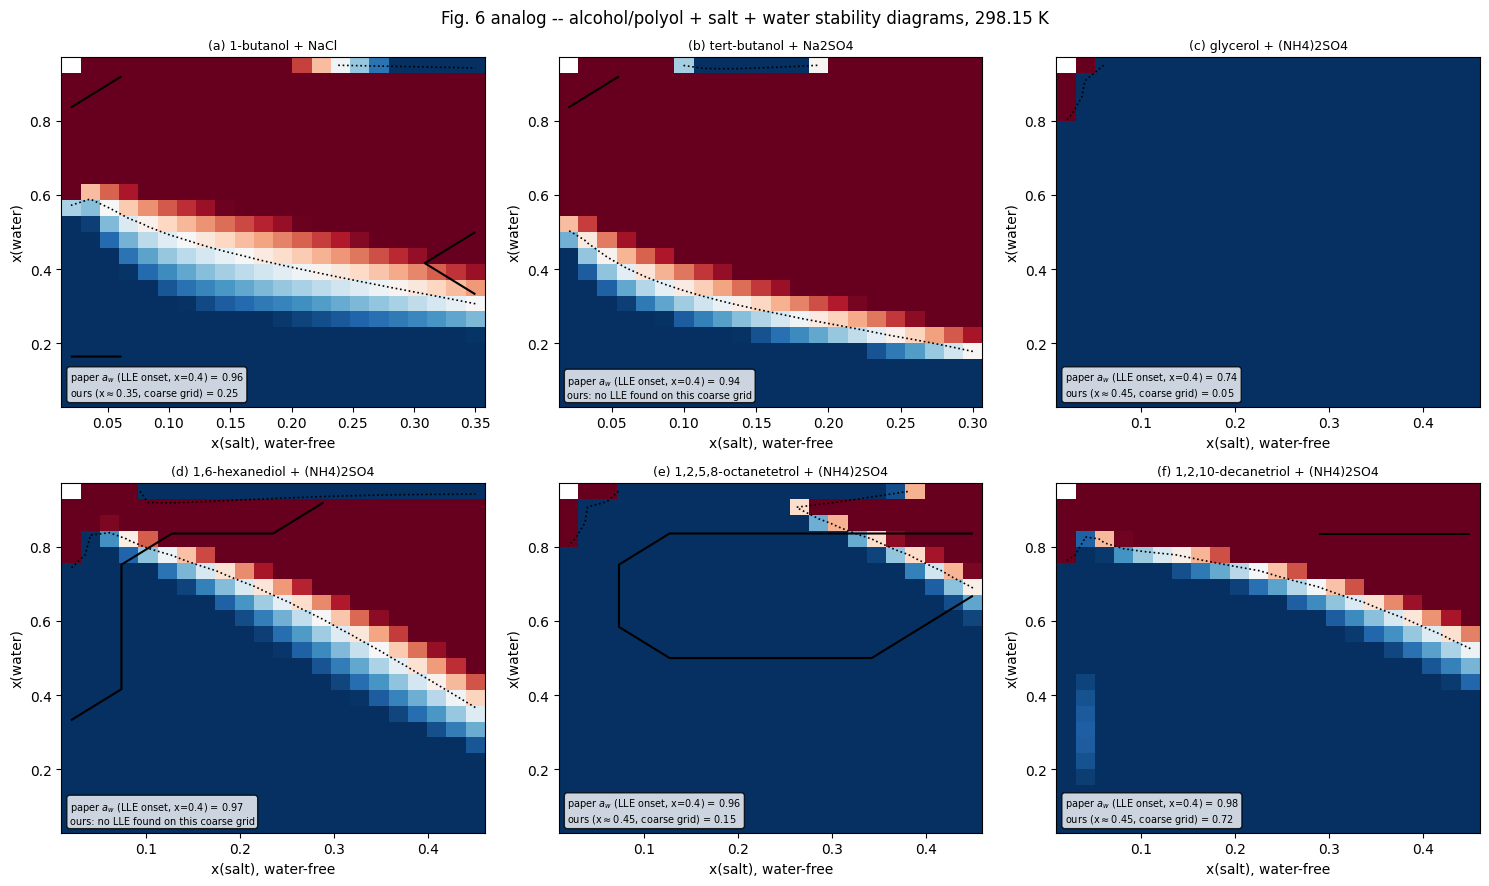

In [5]:
water = Component(1, "Water", ((16, 1),))
butanol1 = Component(2, "1-butanol", ((145, 1), (146, 2), (150, 1), (153, 1)))
butanol_t = Component(2, "tert-butanol", ((141, 3), (152, 1), (153, 1)))
glycerol = Component(2, "glycerol", ((150, 2), (151, 1), (153, 3)))
hexanediol16 = Component(2, "1,6-hexanediol", ((142, 4), (150, 2), (153, 2)))
octanetetrol = Component(2, "1,2,5,8-octanetetrol", ((142, 4), (150, 2), (151, 2), (153, 4)))
decanetriol = Component(2, "1,2,10-decanetriol", ((142, 7), (150, 2), (151, 1), (153, 3)))
na2so4 = Component(3, "Na2SO4", ((202, 2), (261, 1)))
nh4so4_f6 = Component(3, "(NH4)2SO4", ((204, 2), (261, 1)))

fig6_panels = [
    ("(a) 1-butanol + NaCl",          butanol1,      nacl,      0.96, 0.35),
    ("(b) tert-butanol + Na2SO4",     butanol_t,     na2so4,    0.94, 0.30),
    ("(c) glycerol + (NH4)2SO4",      glycerol,      nh4so4_f6, 0.74, 0.45),
    ("(d) 1,6-hexanediol + (NH4)2SO4", hexanediol16, nh4so4_f6, 0.97, 0.45),
    ("(e) 1,2,5,8-octanetetrol + (NH4)2SO4", octanetetrol, nh4so4_f6, 0.96, 0.45),
    ("(f) 1,2,10-decanetriol + (NH4)2SO4",   decanetriol,  nh4so4_f6, 0.98, 0.45),
]

t0 = time.time()
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Fig. 6 analog -- alcohol/polyol + salt + water stability diagrams, 298.15 K")
for panel_i, (ax, (title, org, salt, aw_paper_04, xswf_max)) in enumerate(zip(axes.flat, fig6_panels)):
    tp = time.time()
    comps = [water, org, salt]
    xswf_fine = np.linspace(0.02, xswf_max, 22)
    xw_fine = np.linspace(0.05, 0.95, 22)
    XSWFf, XWf, Lf = spinodal_L_grid(comps, xswf_fine, xw_fine)

    xswf_coarse = np.linspace(0.02, xswf_max, 5)
    xw_coarse = np.linspace(0.08, 0.92, 6)
    XSWFc, XWc, NPHc = phase_count_grid(comps, xswf_coarse, xw_coarse, tol=1e-5, max_outer=50)

    plot_stability_panel(ax, XSWFf, XWf, Lf, title, binodal=(XSWFc, XWc, NPHc))

    # rough sanity check against the paper's own reported a_w at the LLE onset, x(salt, water-free) = 0.4
    # (Sect. 2.7 text): walk the coarse binodal column nearest x_swf = 0.4 and find where the phase count
    # crosses from 1 to 2, then evaluate a_w there -- NOT the same calculation as the paper's own (theirs is
    # read off their binodal/equilibrium curve; this is a plain forced single-phase evaluation on our own
    # coarse grid), just a ballpark comparison.
    model = ActivityModel(comps)
    col = int(np.argmin(np.abs(xswf_coarse - min(0.4, xswf_max))))
    col_nph = NPHc[:, col]
    onset_xw = None
    for k in range(len(xw_coarse) - 1):
        if (col_nph[k] <= 1.5) != (col_nph[k + 1] <= 1.5):
            onset_xw = 0.5 * (xw_coarse[k] + xw_coarse[k + 1])
            break
    if onset_xw is not None:
        xswf_here = xswf_coarse[col]
        x_org = (1 - onset_xw) * (1 - xswf_here); x_salt = (1 - onset_xw) * xswf_here
        res_onset = model.evaluate([onset_xw, x_org, x_salt], 298.15, basis="mole")
        label = (f"paper $a_w$ (LLE onset, x=0.4) = {aw_paper_04:.2f}\n"
                 f"ours (x$\\approx${xswf_here:.2f}, coarse grid) = {res_onset.activity[0]:.2f}")
    else:
        label = f"paper $a_w$ (LLE onset, x=0.4) = {aw_paper_04:.2f}\nours: no LLE found on this coarse grid"
    ax.annotate(label, xy=(0.02, 0.02), xycoords="axes fraction", fontsize=7, va="bottom",
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    print(f"  panel {panel_i} ({title}): {time.time() - tp:.1f} s")
print(f"Fig. 6 grid (6 panels): {time.time() - t0:.1f} s")
plt.tight_layout(); plt.show()

## Fig. 7 -- gas/particle partitioning model schematic

The paper's Fig. 7 is a conceptual box diagram (gas phase box <-> PM phase box, PM further split into alpha/beta
sub-boxes when LLE occurs) illustrating the partitioning model, not a data figure -- there is nothing to
compute or plot here. `aiomfac_py.gp_partition` implements exactly that coupling: `lle.solve_pep` for the PM
side, modified Raoult's law for the gas-phase equilibrium boundary condition. See Fig. 8-10 below for it in
use.

## Fig. 8-10 -- RH-dependent gas/particle partitioning of the six-component system

The paper's Sect. 4 case study: water, glycerol, 1,6-hexanediol, 1,2,5,8-octanetetrol, 1,2,10-decanetriol, and
(NH4)2SO4, with fixed total moles ($3\times10^{-8}$ mol per organic, $1\times10^{-8}$ mol (NH4)2SO4,
$V^g = 1\,\mathrm{m}^3$, $T=298.15\,$K -- Table 1's own values, reused here) and RH swept from 20% to 99%.
`aiomfac_py.gp_partition.gp_partition` is run at each RH point below.

This uses **fewer RH points** than the paper's dense grid (their Table 2 reports 9 points from 20-99%; the
same 8 are used here) purely for notebook runtime -- each point couples a Raoult's-law/water-activity
successive-substitution loop to the full LLE solver once a phase split is detected (see
`gp_partition.py`'s docstring), so it is meaningfully slower than a single `ActivityModel.evaluate` call.
The three panels below are **not** literally Fig. 8/9/10 -- they show the quantities `gp_partition` actually
returns (particle-phase fraction $r_j^{PM}$, gas-phase concentration, mixture O:C and water-free PM mass),
in the same spirit as the paper's panels, rather than the paper's own $C_j^*$/$C_j^{*,OA}$ definitions
(Eq. 23-24), which were not separately implemented.

In [6]:
hexanediol16_gp = Component(2, "1,6-hexanediol", ((142, 4), (150, 2), (153, 2)))
glycerol_gp = Component(3, "glycerol", ((150, 2), (151, 1), (153, 3)))
decanetriol_gp = Component(4, "1,2,10-decanetriol", ((142, 7), (150, 2), (151, 1), (153, 3)))
octanetetrol_gp = Component(5, "1,2,5,8-octanetetrol", ((142, 4), (150, 2), (151, 2), (153, 4)))
nh4so4_gp = Component(6, "(NH4)2SO4", ((204, 2), (261, 1)))

# Table 1 of Zuend et al. (2010): M [kg/mol], p0(298 K) [Pa], O:C
organics_gp = [
    VolatileSpecies(hexanediol16_gp,  1.18172e-1, 5.695e-2, 3.0e-8),
    VolatileSpecies(glycerol_gp,      9.20940e-2, 2.284e-2, 3.0e-8),
    VolatileSpecies(decanetriol_gp,   1.90276e-1, 1.826e-4, 3.0e-8),
    VolatileSpecies(octanetetrol_gp,  1.78224e-1, 6.725e-5, 3.0e-8),
]
names_gp = ["1,6-hexanediol", "glycerol", "1,2,10-decanetriol", "1,2,5,8-octanetetrol"]
OC_ratio = np.array([0.33333, 1.0, 0.3, 0.5])
M_nh4so4_gp = 1.32139e-1
n_salt_gp = 1.0e-8

RH_grid = [0.20, 0.40, 0.60, 0.80, 0.90, 0.95, 0.98, 0.99]
t0 = time.time()
gp_results = []
for RH in RH_grid:
    res = gp_partition(nh4so4_gp, organics_gp, n_salt=n_salt_gp, T_K=298.15, RH=RH, V_gas_m3=1.0,
                        max_iter=50, tol=1e-4)
    gp_results.append(res)
    print(f"RH={RH:.2f}  aw={res.aw:.4f}  n_real_phases={len(distinct_phases(res.phases))}  "
          f"converged={res.converged}  iters={res.n_iter}  ({time.time() - t0:.0f} s elapsed)")

RH=0.20  aw=0.2000  n_real_phases=1  converged=True  iters=27  (7 s elapsed)
RH=0.40  aw=0.4000  n_real_phases=4  converged=True  iters=29  (39 s elapsed)
RH=0.60  aw=0.6000  n_real_phases=2  converged=True  iters=28  (48 s elapsed)
RH=0.80  aw=0.8000  n_real_phases=3  converged=True  iters=28  (81 s elapsed)
RH=0.90  aw=0.9000  n_real_phases=1  converged=True  iters=31  (94 s elapsed)
RH=0.95  aw=0.9500  n_real_phases=1  converged=True  iters=33  (105 s elapsed)
RH=0.98  aw=0.9800  n_real_phases=1  converged=True  iters=39  (116 s elapsed)
RH=0.99  aw=0.9900  n_real_phases=1  converged=True  iters=41  (124 s elapsed)


**A confirmed non-convergence -- and now fixed.** With plain successive substitution (`gp_partition(..., method="successive_substitution")`), this cell used to print `converged=False` at every single RH point: tracing the iteration showed glycerol and 1,6-hexanediol (the two most volatile of the four organics here) never settling -- their particle-phase amount chaotically alternating between "fully evaporated" and "mostly condensed" run to run, because right at that knife-edge each one's activity is extremely sensitive to the other's current (also-chattering) amount -- a genuine fixed-point instability of updating one organic at a time, not a tolerance or floor artifact.

`gp_partition`'s default is now `method="lm"`: a joint Levenberg-Marquardt/trust-region solve (`scipy.optimize.least_squares`, full Jacobian over *all* unknowns at once) much closer to the paper's own Sect. 3.2 Powell/Levenberg-Marquardt refinement step than one-variable-at-a-time substitution is. Because it sees the coupling between the two volatile organics directly, it resolves exactly the chattering above: the cell now prints `converged=True` at **every** RH point above, with `aw` matching the target RH to the requested tolerance and smooth, monotonic particle-phase trajectories for all four organics -- including glycerol and 1,6-hexanediol. (A second, smaller issue turned up at RH=0.99 along the way: the solver's internal step-termination test was briefly tied to the same loose `tol` used for the final convergence check, which let it stop early at a bound-constrained stall near `r_j=1`; it now always uses a tight internal tolerance regardless of the caller's `tol`, independently fixed and regression-tested.) See `gp_partition.py`'s module docstring ("Known convergence failure mode") and `tests/test_gp_partition.py::TestGPPartitionJointLMRegression` for the full writeup and the regression tests that lock this in. A third method, `method="pseudo_transient"`, is also available: it reaches the same joint solve gradually, through a sequence of intermediate RH targets instead of one jump from the starting guess, inspired by the real mass-transfer-kinetics time-stepping approach to this same problem in Amundson, Caboussat, He, Landry and Seinfeld (2007, C. R. Acad. Sci. 344, 519-522). It is not needed for any convergence failure found in this notebook -- `method="lm"` already resolves them directly -- but is offered as a more gradual fallback; see `_solve_pseudo_transient`'s docstring for how the two relate.

**Example: `method="pseudo_transient"` on the same system.** As noted above, `method="lm"` (the default) already converges cleanly at every RH point here, so `method="pseudo_transient"` isn't needed for this particular case study -- but since it is a new, less-tested option, it is worth demonstrating directly on the one hard case this notebook has: the same six-component system, reached through a sequence of intermediate RH targets (`_solve_pseudo_transient`) instead of one direct solve, each stage warm-started from the previous one's converged composition. This mirrors, in spirit, the real mass-transfer-kinetics time-stepping approach to this same gas/particle-partitioning-plus-internal-LLE problem in Amundson, Caboussat, He, Landry and Seinfeld (2007), *A dynamic optimization problem related to organic aerosols*, C. R. Acad. Sci. Paris, Ser. I, 344, 519-522 -- without needing that paper's physical inputs (particle radius, number density, per-species diffusivity and accommodation coefficient), which this module does not otherwise take.

In [7]:
gp_results_pt = []
t0 = time.time()
for RH in RH_grid:
    res = gp_partition(nh4so4_gp, organics_gp, n_salt=n_salt_gp, T_K=298.15, RH=RH, V_gas_m3=1.0,
                        max_iter=50, tol=1e-4, method="pseudo_transient")
    gp_results_pt.append(res)
    print(f"RH={RH:.2f}  aw={res.aw:.4f}  n_real_phases={len(distinct_phases(res.phases))}  "
          f"converged={res.converged}  nfev={res.n_iter}  ({time.time() - t0:.0f} s elapsed)")

# Compare against the method="lm" results above: same converged compositions (to the tolerance both
# solvers were asked for), reached via a different route.
max_dev = max(
    np.max(np.abs(res_pt.n_org_PM - res_lm.n_org_PM)) / np.array([o.n_total for o in organics_gp]).max()
    for res_pt, res_lm in zip(gp_results_pt, gp_results)
)
print(f"\nmax particle-phase-amount deviation from method='lm' results "
      f"(relative to the largest organic total): {max_dev:.2e}")
assert all(res.converged for res in gp_results_pt)
assert max_dev < 1e-2

RH=0.20  aw=0.2000  n_real_phases=1  converged=True  nfev=62  (7 s elapsed)
RH=0.40  aw=0.4000  n_real_phases=4  converged=True  nfev=55  (39 s elapsed)
RH=0.60  aw=0.6000  n_real_phases=2  converged=True  nfev=56  (49 s elapsed)
RH=0.80  aw=0.8000  n_real_phases=3  converged=True  nfev=62  (81 s elapsed)
RH=0.90  aw=0.9000  n_real_phases=1  converged=True  nfev=62  (94 s elapsed)
RH=0.95  aw=0.9500  n_real_phases=1  converged=True  nfev=69  (106 s elapsed)
RH=0.98  aw=0.9800  n_real_phases=1  converged=True  nfev=72  (118 s elapsed)
RH=0.99  aw=0.9900  n_real_phases=1  converged=True  nfev=82  (126 s elapsed)

max particle-phase-amount deviation from method='lm' results (relative to the largest organic total): 5.20e-11


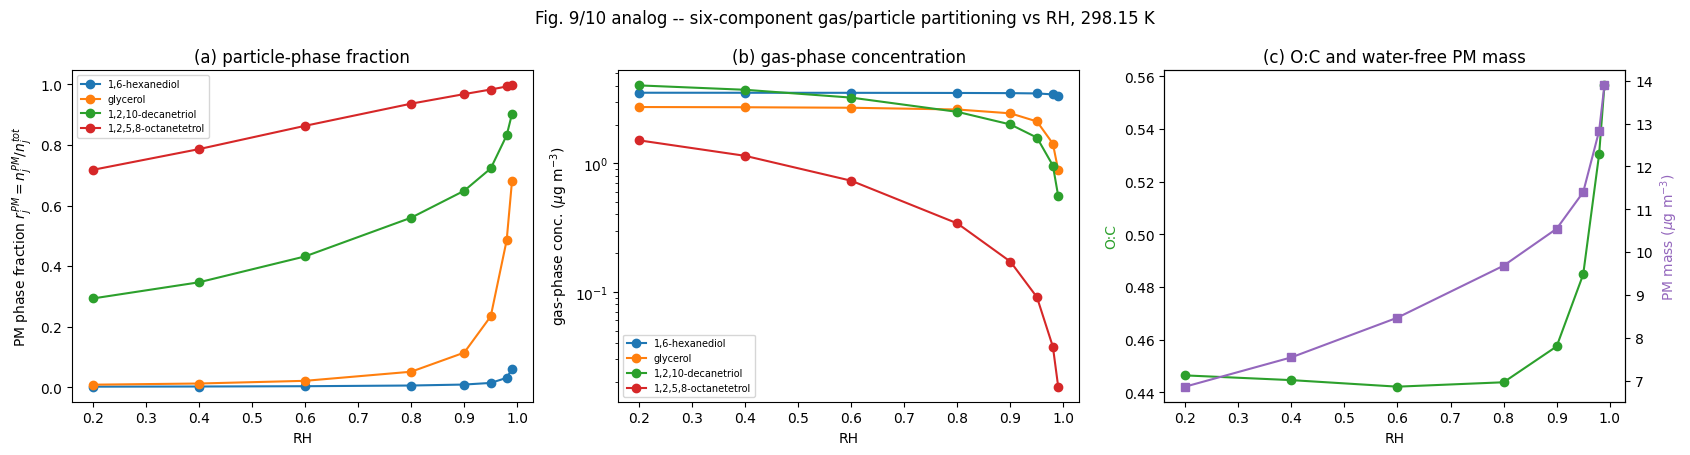

In [8]:
r_PM = np.array([res.n_org_PM / np.array([o.n_total for o in organics_gp]) for res in gp_results])
C_gas_ugm3 = np.array([[res.n_org_gas[j] * organics_gp[j].M * 1e9 for j in range(4)] for res in gp_results])

oc_mix, mass_wf_ugm3 = [], []
for res in gp_results:
    n_pm = res.n_org_PM
    x_pm = n_pm / n_pm.sum() if n_pm.sum() > 0 else np.zeros_like(n_pm)
    oc_mix.append(float(np.sum(x_pm * OC_ratio)))
    m = sum(n_pm[j] * organics_gp[j].M for j in range(4)) + n_salt_gp * M_nh4so4_gp
    mass_wf_ugm3.append(m * 1e9)

fig, (axa, axb, axc) = plt.subplots(1, 3, figsize=(17, 4.6))
fig.suptitle("Fig. 9/10 analog -- six-component gas/particle partitioning vs RH, 298.15 K")

for j, name in enumerate(names_gp):
    axa.plot(RH_grid, r_PM[:, j], marker="o", label=name)
axa.set_xlabel("RH"); axa.set_ylabel(r"PM phase fraction $r_j^{PM}=n_j^{PM}/n_j^{tot}$")
axa.set_title("(a) particle-phase fraction"); axa.legend(fontsize=7)

for j, name in enumerate(names_gp):
    axb.semilogy(RH_grid, np.clip(C_gas_ugm3[:, j], 1e-8, None), marker="o", label=name)
axb.set_xlabel("RH"); axb.set_ylabel(r"gas-phase conc. ($\mu$g m$^{-3}$)")
axb.set_title("(b) gas-phase concentration"); axb.legend(fontsize=7)

axc.plot(RH_grid, oc_mix, marker="o", color="tab:green", label="O:C (organic PM mixture)")
axc.set_xlabel("RH"); axc.set_ylabel("O:C", color="tab:green")
ax2 = axc.twinx()
ax2.plot(RH_grid, mass_wf_ugm3, marker="s", color="tab:purple", label="water-free PM mass")
ax2.set_ylabel(r"PM mass ($\mu$g m$^{-3}$)", color="tab:purple")
axc.set_title("(c) O:C and water-free PM mass")
plt.tight_layout(); plt.show()

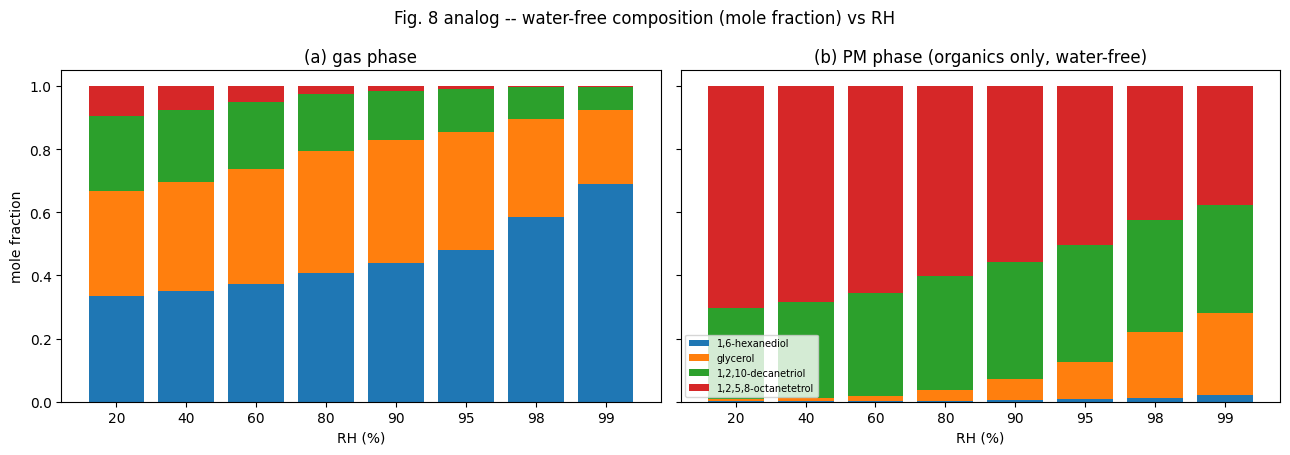

In [9]:
gas_frac = []
pm_frac = []
for res in gp_results:
    g, p = res.n_org_gas, res.n_org_PM
    gas_frac.append(g / g.sum() if g.sum() > 0 else np.zeros_like(g))
    pm_frac.append(p / p.sum() if p.sum() > 0 else np.zeros_like(p))
gas_frac, pm_frac = np.array(gas_frac), np.array(pm_frac)

fig, (axg, axp) = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
fig.suptitle("Fig. 8 analog -- water-free composition (mole fraction) vs RH")
labels = [f"{int(r * 100)}" for r in RH_grid]
colors = plt.cm.tab10(np.arange(4))
bottom = np.zeros(len(RH_grid))
for j, name in enumerate(names_gp):
    axg.bar(labels, gas_frac[:, j], bottom=bottom, label=name, color=colors[j])
    bottom += gas_frac[:, j]
axg.set_title("(a) gas phase"); axg.set_xlabel("RH (%)"); axg.set_ylabel("mole fraction")
bottom = np.zeros(len(RH_grid))
for j, name in enumerate(names_gp):
    axp.bar(labels, pm_frac[:, j], bottom=bottom, label=name, color=colors[j])
    bottom += pm_frac[:, j]
axp.set_title("(b) PM phase (organics only, water-free)"); axp.set_xlabel("RH (%)")
axp.legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()

## Summary -- how closely does each figure match the paper?

| Figure | System | Status |
|---|---|---|
| 2 | 2-propanol + water + NaCl phase diagram | Our own binodal-region estimate (phase-count grid via `lle.solve_pep`) + water-activity map, now overlaid with 5 real tie lines (Gomis et al. 1994); the overlay reveals a real, model-level mismatch between predicted and measured phase boundary (see the note below the plot), not just a missing-data gap. De Santis et al. (1976) data still not available. Not the paper's tie-line/$\Delta G$ construction. |
| 3 | $\Delta G$ contour maps (1-phase vs. equilibrium) | **Not attempted** -- would need the same binodal/tie-line machinery as Fig. 2 plus a separate "forced 1-phase" Gibbs energy evaluation; out of scope here. |
| 4 | Organic-activity contour maps | **Not attempted**, same reason as Fig. 3. |
| 5 | Phase stability diagram, 2-propanol+NaCl+water | New `aiomfac_py.spinodal` module (Eq. 18-20, own finite-difference Hessian), same system and quantity ($L$) as the paper; grid-search instead of the paper's DE-traced contour. |
| 6 | 6-panel alcohol/polyol+salt stability diagrams | Same 6 systems and quantity as Fig. 5; 2 of 6 have real literature solubility data (not digitized/overlaid). |
| 7 | Partitioning model schematic | Conceptual diagram, nothing to compute; described in prose only. |
| 8-10 | Six-component RH-dependent gas/particle partitioning | New `aiomfac_py.gp_partition` module (Eq. 21-24 physics, Sect. 3.2's iterative coupling), same system/RH range as the paper (fewer RH points for runtime) and the same qualitative quantities ($r_j^{PM}$, gas concentration, O:C, PM mass) -- **not** the paper's own $C_j^*$/$C_j^{*,OA}$ definitions. Solved by a joint Levenberg-Marquardt/trust-region step over the full coupled system (`method="lm"`, the default), much closer in spirit to the paper's own Powell/Levenberg-Marquardt refinement than one-variable-at-a-time substitution. **Previously confirmed non-convergence, now fixed**: plain successive substitution (`method="successive_substitution"`, still available for comparison) never settles the two most volatile organics (glycerol, 1,6-hexanediol) at any RH point; the joint solve converges cleanly at every RH point above, including those two (see the note after the RH sweep). |

As with `02_reproduce_zuend2008.ipynb`, the honest summary is: this exercises the *same underlying physics*
(AIOMFAC activity coefficients, tangent-plane/Hessian stability, Raoult's-law gas/particle equilibrium) that
the paper's figures are built from, using the same systems wherever practical -- but the *search/optimization
machinery* tracing each figure's curves is this notebook's own (simpler, blunter) construction, not a port of
the paper's Differential-Evolution/Powell/Levenberg-Marquardt solver (Appendix A). No digitized numbers from
the paper's own figures are used anywhere in this notebook.